# 03 - Visualization
**Goal:** answer questions about Netflix's catalog with charts, and write one insight under each.

In [4]:
import calendar

import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns
from wordcloud import STOPWORDS, WordCloud

sns.set_theme(style="whitegrid")
RED, DARK = "#E50914", "#221f1f"

df = pd.read_csv("C:\\Users\\sreej\\codetech_projects\\NetflixContentVisualization\\netflix_content_visualization\\data\\processed\\netflix_cleaned.csv", parse_dates=["date_added"])
print(df.shape)


def save_fig(name):
    plt.tight_layout()
    plt.savefig(f"C:\\Users\\sreej\\codetech_projects\\NetflixContentVisualization\\netflix_content_visualization\\images/{name}.png", dpi=150, bbox_inches="tight")

(8797, 20)


## 1. Movies vs TV Shows

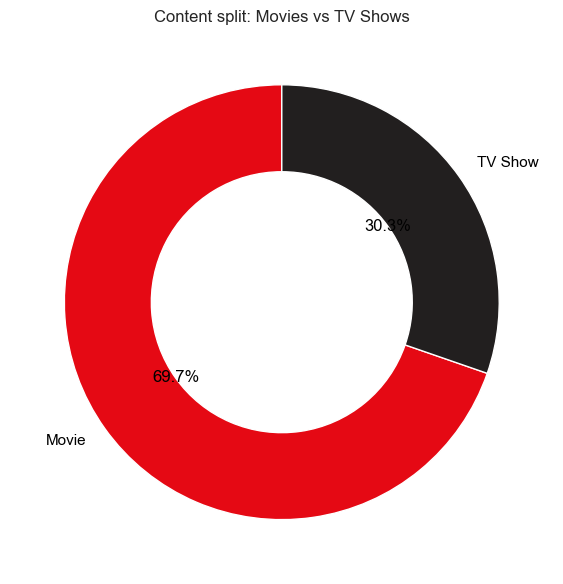

In [5]:
counts = df["type"].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    counts, labels=counts.index, autopct="%1.1f%%", startangle=90,
    colors=[RED, DARK], wedgeprops=dict(width=0.4), textprops=dict(color="black"),
)
ax.set_title("Content split: Movies vs TV Shows")
save_fig("01_type_split")
plt.show()

**Insight:**
- Movies make up about **70%** of the catalog and TV shows about **30%**, so Netflix's library is movie-heavy.
- Movies are more than twice as common as TV shows.

## 2. Titles added per year

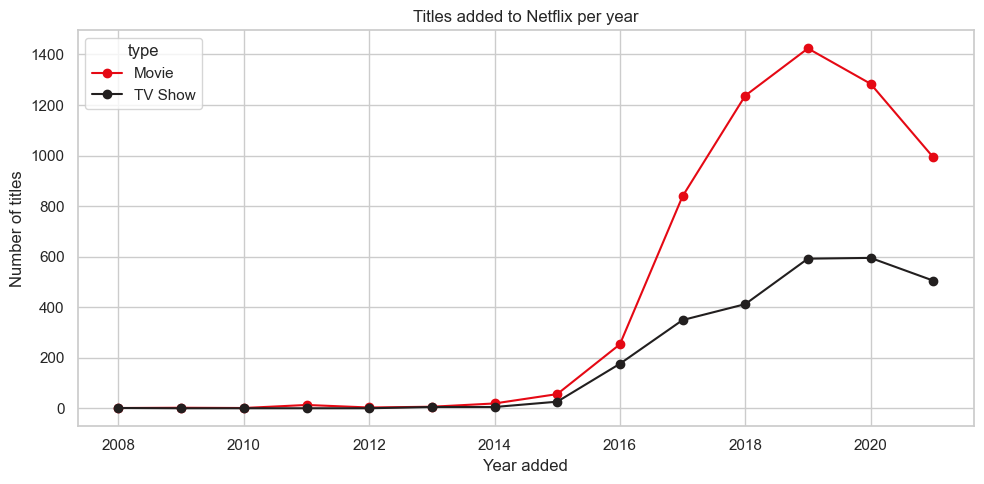

In [6]:
yearly = df.groupby(["year_added", "type"]).size().unstack(fill_value=0)

ax = yearly.plot(kind="line", marker="o", figsize=(10, 5), color=[RED, DARK])
ax.set_title("Titles added to Netflix per year")
ax.set_xlabel("Year added")
ax.set_ylabel("Number of titles")
save_fig("02_titles_per_year")
plt.show()

**Insight:**
- Additions were negligible before 2015 (well under 100 titles a year), then **took off from 2016**.
- Movie additions **peaked in 2019 (~1,425 titles)** and TV show additions peaked around **2019-2020 (~590-600 titles)**.
- Movies were added at roughly 2-3x the rate of TV shows in every year from 2016 onward.
- Both lines drop in 2021, but the data only runs to about September 2021, so that dip is partly an incomplete year. The movie decline starting in 2020 is real.

## 3. Which months get the most additions?

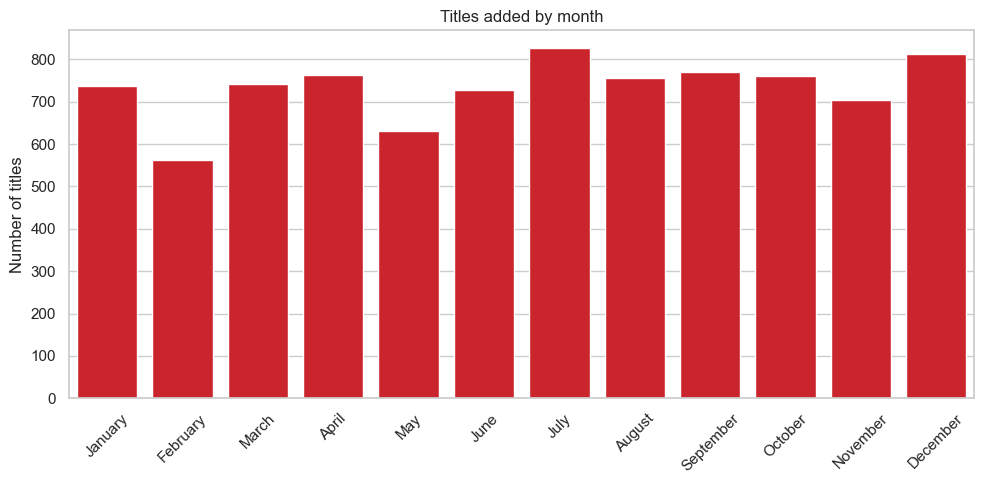

In [7]:
month_order = list(calendar.month_name)[1:]
monthly = df["month_name"].value_counts().reindex(month_order, fill_value=0)

plt.figure(figsize=(10, 5))
sns.barplot(x=monthly.index, y=monthly.values, color=RED)
plt.xticks(rotation=45)
plt.title("Titles added by month")
plt.xlabel("")
plt.ylabel("Number of titles")
save_fig("03_titles_per_month")
plt.show()

**Insight:**
- Additions are fairly even across the year (~700-770 titles in most months), so there is **no strong seasonality**.
- **July (~825) and December (~810)** are the busiest months, possibly aligned with summer and holiday viewing.
- **February (~560)** is the quietest month, followed by May (~630). February is also the shortest month.

## 4. Top 10 countries


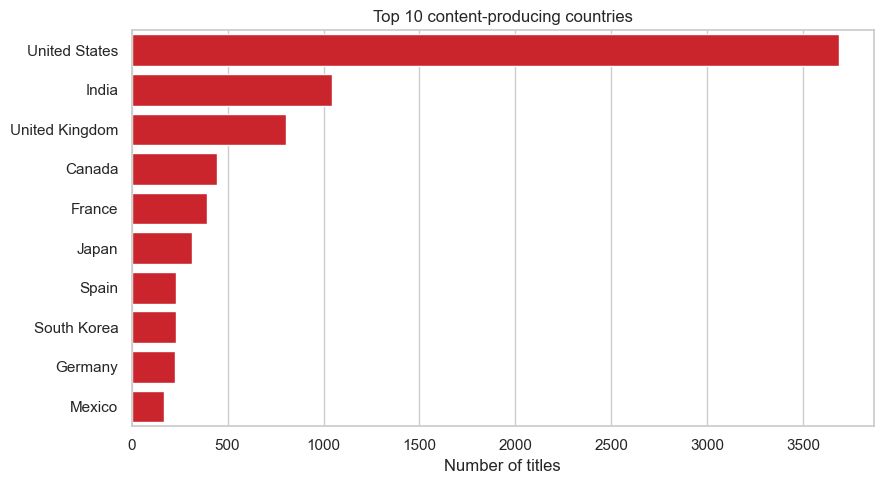

In [8]:
# A title can have several countries, so split and explode first
countries = df["country"].str.split(",").explode().str.strip()
countries = countries[(countries != "Unknown") & (countries != "")]
top_countries = countries.value_counts().head(10)

plt.figure(figsize=(9, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, color=RED)
plt.title("Top 10 content-producing countries")
plt.xlabel("Number of titles")
plt.ylabel("")
save_fig("04_top_countries")
plt.show()

**Insight:**
- The **United States dominates with ~3,700 titles**, about 3.5x more than second-place India (~1,050).
- The top three are the US, India and the UK (~800). Canada, France and Japan follow with ~300-450 each.
- South Korea, Spain, Germany and Mexico are around 170-230 each.
- A co-production is counted once for each country involved, so these counts add up to more than the number of titles.

## 5. Top 10 genres

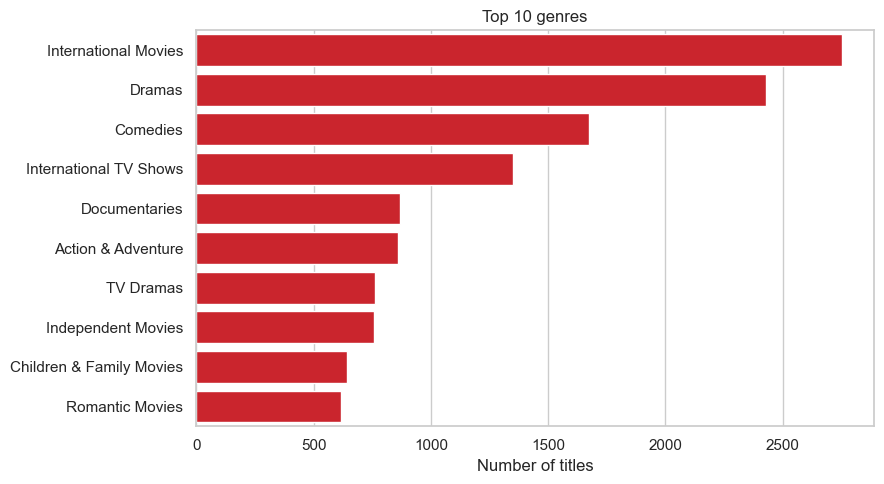

In [9]:
genres = df["listed_in"].str.split(",").explode().str.strip()
top_genres = genres.value_counts().head(10)

plt.figure(figsize=(9, 5))
sns.barplot(x=top_genres.values, y=top_genres.index, color=RED)
plt.title("Top 10 genres")
plt.xlabel("Number of titles")
plt.ylabel("")
save_fig("05_top_genres")
plt.show()

**Insight:**
- **International Movies (~2,750)** and **Dramas (~2,430)** are the two biggest genres, followed by Comedies (~1,670).
- "International" content appears twice in the top 4 (movies and TV shows), showing Netflix's strategy of building a global library.
- Only two of the top ten labels are TV-specific (International TV Shows, TV Dramas), which matches the movie-heavy catalog.
- A title can have several genres, so counts overlap.

## 6. Rating distribution

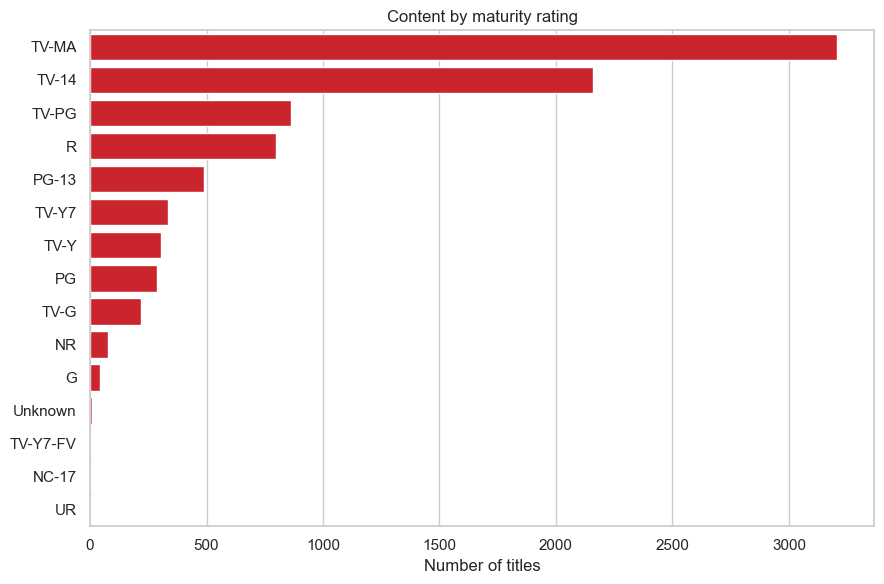

In [11]:
order = df["rating"].value_counts().index

plt.figure(figsize=(9, 6))
sns.countplot(data=df, y="rating", order=order, color=RED)
plt.title("Content by maturity rating")
plt.xlabel("Number of titles")
plt.ylabel("")
save_fig("06_ratings")
plt.show()

**Insight:**
- Netflix content leans **toward adult and teen audiences**. **TV-MA (~3,200)** and **TV-14 (~2,160)** together make up about 60% of titles.
- Kids and family ratings (TV-Y, TV-Y7, TV-G, G, PG) total only about 1,200 titles, roughly 1 in 7.
- Ratings like NR, TV-Y7-FV, NC-17 and UR have almost no titles and could be grouped as "Other".

## 7. Movie duration

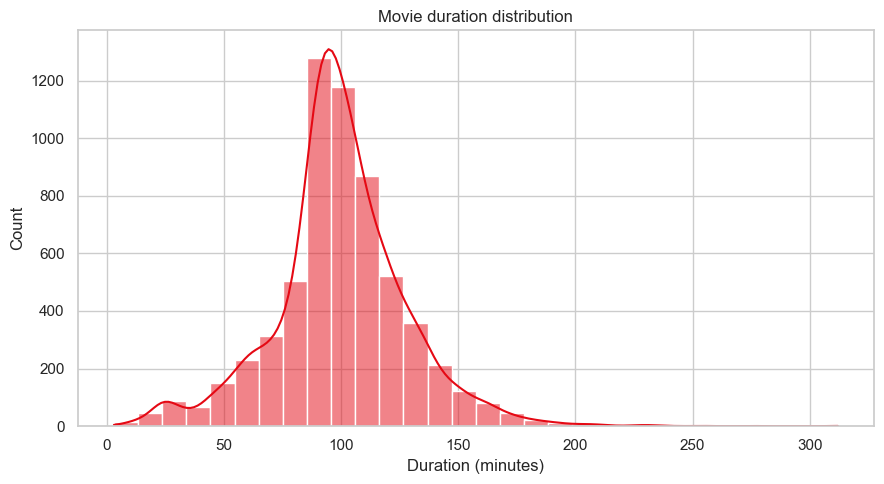

Median movie length: 98.0 minutes


In [12]:
movies = df[df["type"] == "Movie"].dropna(subset=["duration_min"])

plt.figure(figsize=(9, 5))
sns.histplot(movies["duration_min"], bins=30, kde=True, color=RED)
plt.title("Movie duration distribution")
plt.xlabel("Duration (minutes)")
save_fig("07_movie_duration")
plt.show()

print("Median movie length:", movies["duration_min"].median(), "minutes")

**Insight:**
- The **median movie length is 98 minutes**, and the distribution peaks around **90-100 minutes**, the standard feature-film length.
- Most movies fall between roughly 75 and 130 minutes.
- The distribution has a long right tail with a few very long titles (up to ~300 minutes), and a small bump around 25 minutes, likely short films and specials.

## 8. Seasons per TV show

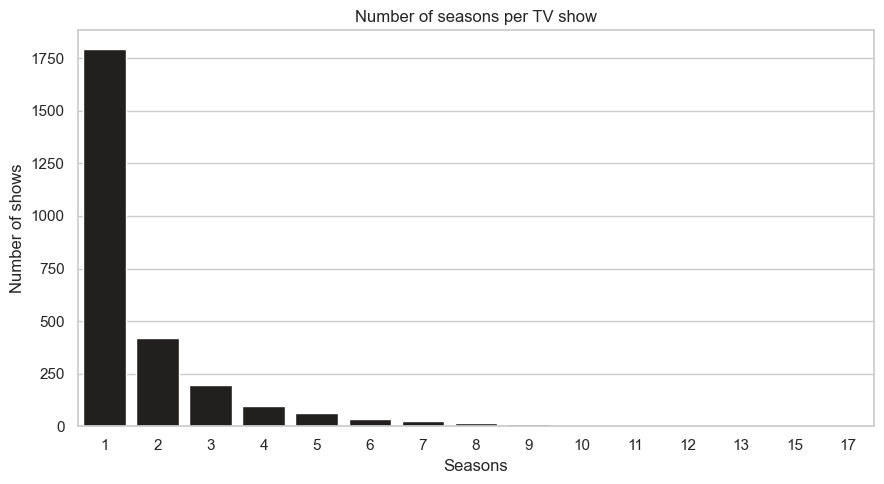

In [14]:
tv = df[df["type"] == "TV Show"].dropna(subset=["seasons"]).copy()
tv["seasons"] = tv["seasons"].astype(int)

plt.figure(figsize=(9, 5))
sns.countplot(data=tv, x="seasons", color=DARK)
plt.title("Number of seasons per TV show")
plt.xlabel("Seasons")
plt.ylabel("Number of shows")
save_fig("08_tv_seasons")
plt.show()

**Insight:**
- About **two-thirds of TV shows have just 1 season** (~1,790), and only about 16% reach 2 seasons.
- The number of shows drops steadily with each extra season. Very few go beyond 5 seasons, and the longest has 17.
- Many shows are recent or limited series, so 1 season does not always mean the show was cancelled.

## 9. How old is the content when Netflix adds it?

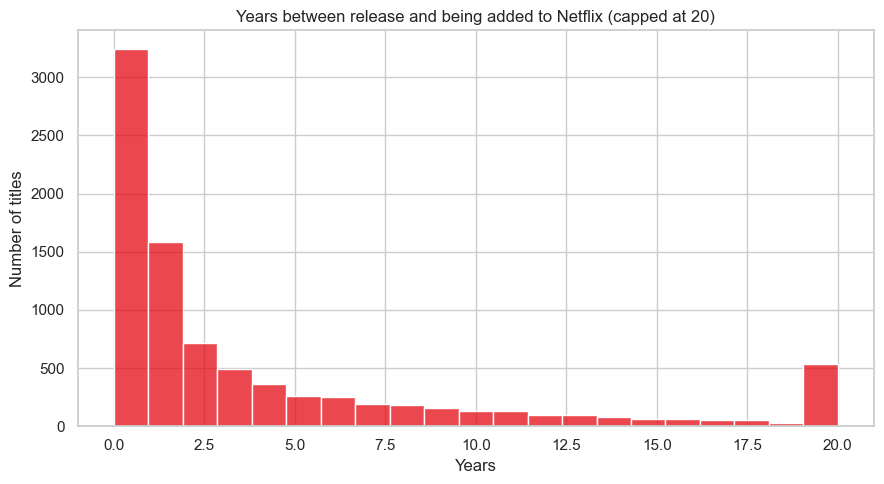

In [15]:
lag = (df["year_added"] - df["release_year"])
lag = lag[lag >= 0].clip(upper=20)   # ignore negatives; group anything older than 20 years

plt.figure(figsize=(9, 5))
sns.histplot(lag, bins=21, color=RED)
plt.title("Years between release and being added to Netflix (capped at 20)")
plt.xlabel("Years")
plt.ylabel("Number of titles")
save_fig("09_release_lag")
plt.show()

**Insight:**
- Netflix mostly adds **fresh content**. About **3,250 titles** (roughly 37%) were added in the same year they were released, and over half within about 2 years.
- The number of titles falls steadily as the gap grows, so older titles are added only occasionally.
- About 530 titles were released **20 or more years** before being added, mostly licensed catalog content.

## 10. Word cloud of descriptions

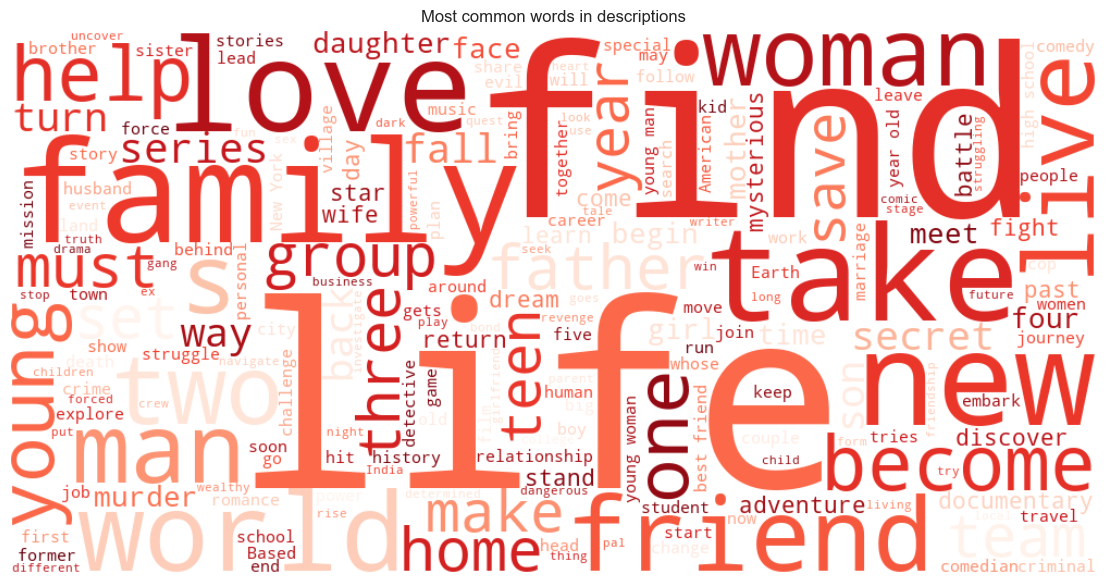

In [16]:
text = " ".join(df["description"].dropna())

wc = WordCloud(
    width=1000, height=500, background_color="white",
    stopwords=STOPWORDS, colormap="Reds",
).generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Most common words in descriptions")
save_fig("10_wordcloud")
plt.show()

## 11. World map of content

C:\Users\sreej\AppData\Local\Temp\ipykernel_816\286511300.py:4: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


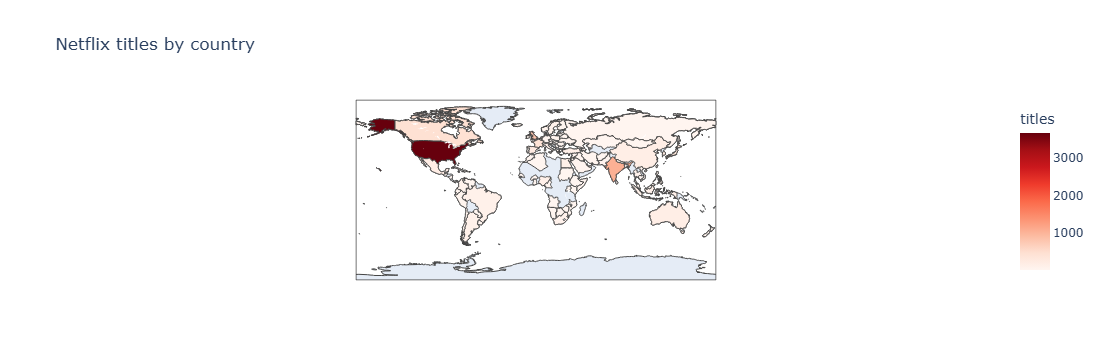

In [17]:
country_counts = countries.value_counts().reset_index()
country_counts.columns = ["country", "titles"]

fig = px.choropleth(
    country_counts, locations="country", locationmode="country names",
    color="titles", color_continuous_scale="Reds",
    title="Netflix titles by country",
)
fig.write_html("../images/11_world_map.html")
fig.show()

## Key Findings

1. **Movie-heavy catalog:** about 70% of titles are movies and 30% are TV shows.
2. **Rapid growth after 2015:** additions were minimal before 2015, jumped from 2016, and peaked around 2019-2020, with movie additions reaching ~1,425 titles in 2019.
3. **No strong seasonality:** additions are spread evenly across months, with small peaks in July and December and a dip in February.
4. **US dominance:** the US produced ~3,700 titles, about 3.5x more than India, the second-largest country. Together with the UK, the top 3 lead by a wide margin.
5. **Drama, comedy and international content lead:** International Movies and Dramas are the two biggest genres.
6. **Mature audience focus:** TV-MA and TV-14 cover about 60% of titles, while kids and family ratings cover only about 1 in 7.
7. **Standard movie length:** the median movie runs 98 minutes.
8. **Short-lived series:** about two-thirds of TV shows have only one season.
9. **Fresh content:** over half of titles were added within about 2 years of release.

## Limitations
- The data ends around September 2021, so 2021 is an incomplete year.
- Titles with several countries or genres are counted once per value, so counts overlap.
- Country, director and cast had missing values, filled with "Unknown" and excluded from country charts.
- The dataset shows the catalog at one point in time. It does not include viewership, so it says what Netflix *offers*, not what people *watch*.

## Conclusion
Netflix's catalog is dominated by recent, mature-rated, US-produced movies, but a growing international presence (India, UK, and other countries) and a strong presence of international genres show a clear shift toward a global content library.